In [26]:
# importing...
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
# known data stating here...
# setting gpu or cpu (setting up device-agnostic code)
device = "cuda" if torch.cuda.is_available() else "cpu"
w = 0.65
b = 0.25
x = torch.arange(1, 9, 0.02, device=device).unsqueeze(dim=1)
y = x * w + b

400

In [28]:
# split data to train, test for x and y -> 80% of train and 20% for test

train_split = int(0.8 * len(x))
x_train, y_train = x[: train_split], y[: train_split]
x_test, y_test = x[train_split :], y[train_split :]

len(x_train), len(y_train), len(x_test), len(y_test)

(320, 320, 80, 80)

In [29]:
# writing plot graph function to view data splitted and when training outcome

def plot_predictions(train_data=x_train, train_labels=y_train, test_data=x_test, test_labels=y_test, predictions=None):
    # for training data plot -> train_data vs train_labels on blue color(c ="b"), s=4 for size of the point
    plt.scatter(train_data, train_labels, c="b", s=2, label="Training data...")
    # for testing data plot -> test_data vs test_labels on green color(c="g") "............................."
    plt.scatter(test_data, test_labels, c="g", s=2, label="Testing data...")

    # plot prediction on red -> x vs y (which means x is the test_data, and prediction is the labels)-> input(x), target(y)
    if predictions is not None:
      plt.scatter(test_data, predictions, c="r", s=2, label="Predictions")
    plt.legend(prop={"size": 14})


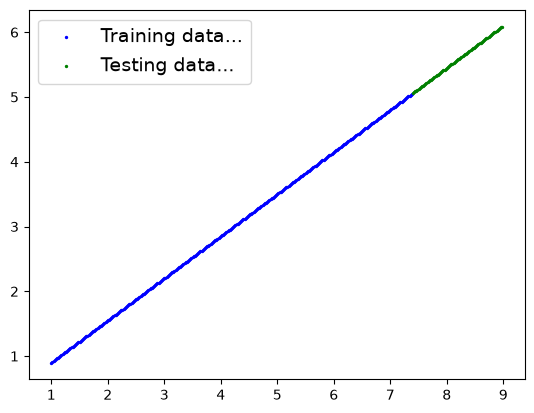

In [30]:
plot_predictions()

In [31]:
# writing the class model

class LinearRegression(nn.Module):

    def __init__(self):
        super().__init__()
        self.w = nn.Parameter(torch.randn(1, dtype=torch.float, device=device))
        self.b = nn.Parameter(torch.randn(1, dtype=torch.float, device=device))

    def forward(self, x : torch.Tensor) -> torch.Tensor:
        return (x * self.w + self.b)

In [32]:
# instance the model
# and putting manual_seed(24)
torch.manual_seed(24)
model = LinearRegression()
# creating loss function using nn.L1Loss to calculate Mean Absolute Error: MAE
loss_fn = nn.L1Loss()
# making optimizer with SDG for randomly updating the parameters -> w and b and with lr = 0.001(learning rate)
optimizer = optim.SGD(model.parameters(), lr=0.001)

In [33]:
# training the model with epoch of 1000 and creating the plot of the loss

epochs = 1000
epoch_count = []
train_loss = []
test_loss = []

for epoch in range(epochs):
    # model train mode turn on for backnorm and drops -> like dropping layers to make our model learn not cram
    model.train()
    # making prediction
    y_preds = model(x_train)
    # loss function calculating (input, target)
    loss = loss_fn(y_preds, y_train)
    # erasing the accumulated grad or gradients before calculating new grad to avoid error in grad calculations
    optimizer.zero_grad()
    # calculating grad by backpropagation from the loss
    loss.backward()
    # now updating the model with the new w and b from the grad calculation from backpropagation
    optimizer.step()

    # testing mode
    model.eval()
    # turning on the inference_mode() to avoid backpropagation track or gradient tracking
    with torch.inference_mode():   
    # making pred
      test_preds = model(x_test)
    # calculating loss
      testLoss = loss_fn(test_preds, y_test)

    # saving the loss value per 10 steps
    if epoch % 100 == 0:
       epoch_count.append(epoch)
       train_loss.append(loss.item())
       test_loss.append(testLoss.item())

(OrderedDict([('w', tensor([0.6029])), ('b', tensor([0.4970]))]), 0.65, 0.25)

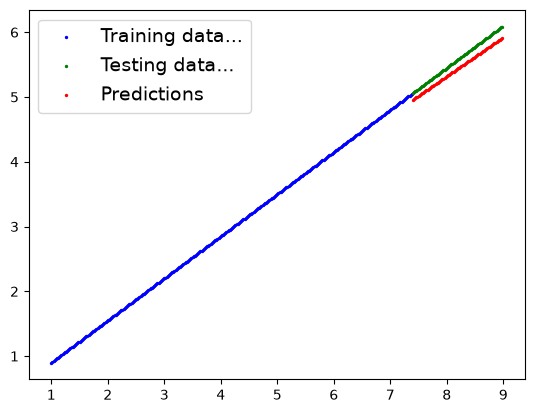

In [34]:
# testing and turning on the inference_mode()
with torch.inference_mode():
    y_preds = model(x_test)


plot_predictions(predictions=y_preds)
model.state_dict(), w, b

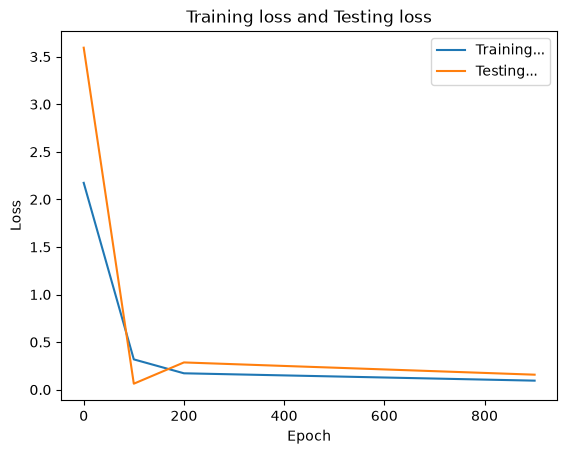

In [35]:
# plotting loss graph training
plt.plot(epoch_count, train_loss, label="Training...")
plt.plot(epoch_count, test_loss, label="Testing...")
plt.title("Training loss and Testing loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()


In [36]:
# saving model

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)
MODEL_NAME = "model_one.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

if MODEL_SAVE_PATH is not None:
    torch.save(obj=model.state_dict(), f=MODEL_SAVE_PATH)

In [37]:
# loading model

# creating new brand model

model_two = LinearRegression()
# loading the state_dict into it
model_two.load_state_dict(torch.load(f=MODEL_SAVE_PATH))



<All keys matched successfully>

In [38]:

model_two.state_dict()# testing model
with torch.inference_mode():
    y_pred = model_two(x_test)
y_pred

tensor([[4.9582],
        [4.9702],
        [4.9823],
        [4.9944],
        [5.0064],
        [5.0185],
        [5.0305],
        [5.0426],
        [5.0546],
        [5.0667],
        [5.0788],
        [5.0908],
        [5.1029],
        [5.1149],
        [5.1270],
        [5.1390],
        [5.1511],
        [5.1632],
        [5.1752],
        [5.1873],
        [5.1993],
        [5.2114],
        [5.2234],
        [5.2355],
        [5.2476],
        [5.2596],
        [5.2717],
        [5.2837],
        [5.2958],
        [5.3078],
        [5.3199],
        [5.3320],
        [5.3440],
        [5.3561],
        [5.3681],
        [5.3802],
        [5.3922],
        [5.4043],
        [5.4164],
        [5.4284],
        [5.4405],
        [5.4525],
        [5.4646],
        [5.4766],
        [5.4887],
        [5.5008],
        [5.5128],
        [5.5249],
        [5.5369],
        [5.5490],
        [5.5610],
        [5.5731],
        [5.5852],
        [5.5972],
        [5.6093],
        [5